In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Input

In [ ]:
df = pd.read_csv("../data/featured_personal_loan.csv")

In [ ]:
X = df.drop("Personal.Loan", axis=1)
y = df["Personal.Loan"]
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=1/3,
    random_state=42,
    stratify=y_temp
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

# Build Model Start 

In [ ]:
model = Sequential([
    Input(shape=(11,)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

# Train Model Start

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32
)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

# Testing on Test Data

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import matplotlib.pyplot as plt
import numpy as np

In [82]:
final_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])


final_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

final_model.summary()
history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8460 - loss: 0.8741 - val_accuracy: 0.8910 - val_loss: 0.4110
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8954 - loss: 0.3483 - val_accuracy: 0.9020 - val_loss: 0.2297
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8894 - loss: 0.3820 - val_accuracy: 0.9130 - val_loss: 0.2735
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9200 - loss: 0.2196 - val_accuracy: 0.9120 - val_loss: 0.2097
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9249 - loss: 0.2181 - val_accuracy: 0.8930 - val_loss: 0.2890
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9149 - loss: 0.2289 - val_accuracy: 0.9350 - val_loss: 0.1598
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9311 - loss: 0.1726 - val_accuracy: 0.9370 - val_loss: 0.1530
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9377 - loss: 0.1636 - val_accuracy: 0.

In [83]:
train_loss, train_acc = final_model.evaluate(
    X_train,
    y_train,
    verbose=0
)

val_loss, val_acc = final_model.evaluate(
    X_val,
    y_val,
    verbose=0
)


print("Final Training Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)

print("Final Training Loss:", train_loss)
print("Final Validation Loss:", val_loss)

Final Training Accuracy: 0.9685714244842529
Final Validation Accuracy: 0.9739999771118164
Final Training Loss: 0.08301553875207901
Final Validation Loss: 0.07809838652610779


In [84]:
test_loss, test_acc = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)


print("Final Test Accuracy:", test_acc)
print("Final Test Loss:", test_loss)

Final Test Accuracy: 0.972000002861023
Final Test Loss: 0.07554008811712265


In [85]:
y_pred_probability = final_model.predict(X_test)

y_pred = (y_pred_probability > 0.5).astype(int)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [86]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[446   6]
 [  8  40]]


In [87]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       452
           1       0.87      0.83      0.85        48

    accuracy                           0.97       500
   macro avg       0.93      0.91      0.92       500
weighted avg       0.97      0.97      0.97       500



In [88]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(
    y_test,
    y_pred_probability
)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.972
Precision: 0.8695652173913043
Recall: 0.8333333333333334
F1 Score: 0.851063829787234
ROC-AUC: 0.9876935840707964


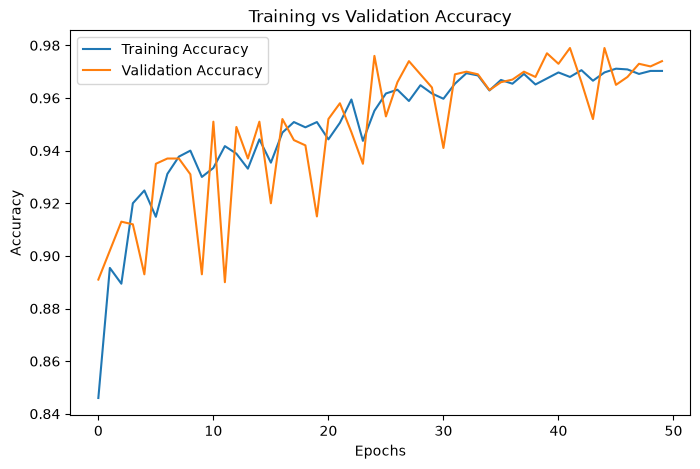

In [89]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)


plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

# Test Outputs Conclusion:

The model achieved 97.2% test accuracy with 0.987 ROC-AUC, indicating excellent classification performance. The confusion matrix shows that the model correctly classified 486 out of 500 samples with only a few false predictions. An F1-score of 0.85 and recall of 0.83 demonstrate that the model is effective in detecting positive cases while maintaining reliable predictions.